In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

def load_data(file_path):
    try:
        df = pd.read_csv(file_path, encoding='latin-1')
        return df
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

def clean_dataset(df):

    print("="*60)
    print("CLEANING DATASET")
    print("="*60)
    
    n_rows = len(df)
    
    # Calculate missing percentages
    missing_pct = (df.isnull().sum() / n_rows * 100).round(2)
    high_missing_cols = missing_pct[missing_pct > 70].index.tolist()
    
    # Drop columns
    initial_cols = df.shape[1]
    df_clean = df.drop(columns=high_missing_cols, errors='ignore')
    final_cols = df_clean.shape[1]
    
    print(f"Dropped {len(high_missing_cols)} columns with >70% missing")
    print(f"Columns before: {initial_cols}, after: {final_cols}")
    
    if high_missing_cols:
        print(f"\nDropped columns:")
        for col in high_missing_cols[:10]:
            print(f"  • {col} ({missing_pct[col]}% missing)")
        if len(high_missing_cols) > 10:
            print(f"  ... and {len(high_missing_cols)-10} more")
    
    return df_clean

def generate_data_quality_report(df_clean):
    """
    Generate quality report on the CLEANED dataset
    """
    print("\n" + "="*60)
    print("DATA QUALITY REPORT (on Cleaned Dataset)")
    print("="*60)
    
    n_rows, n_cols = df_clean.shape
    print(f"Cleaned Dataset: {n_rows} rows × {n_cols} columns")
    
    
    
    # 1. MISSING VALUE ANALYSIS (on cleaned data)
    print("\n" + "-"*40)
    print("1. MISSING VALUE ANALYSIS")
    print("-"*40)
    
    missing_counts = df_clean.isna().sum()
    missing_pct = (missing_counts / n_rows * 100).round(2)
    
    missing_df = pd.DataFrame({
        'Missing_Count': missing_counts,
        'Missing_Percentage': missing_pct
    }).sort_values('Missing_Percentage', ascending=False)
    
    top_missing = missing_df[missing_df['Missing_Count'] > 0].head(10)
    if not top_missing.empty:
        print("Top columns with missing values:")
        print(top_missing.to_string())
    else:
        print("No missing values in cleaned dataset")
        
        
    
    # 2. DUPLICATE RECORD CHECKS (on cleaned data)
    print("\n" + "-"*40)
    print("2. DUPLICATE RECORD ANALYSIS")
    print("-"*40)
    
    # Full row duplicates
    full_duplicates = df_clean.duplicated().sum()
    print(f"• Full row duplicates: {full_duplicates} ({full_duplicates/n_rows*100:.1f}%)")
    
    # Check key columns for duplicates
    key_columns = ['SEVIS_ID', 'NonImmigrant_ID', 'FIN_ID']
    existing_keys = [col for col in key_columns if col in df_clean.columns]
    
    for col in existing_keys:
        dup_count = df_clean[col].duplicated().sum()
        unique_count = df_clean[col].nunique()
        print(f"• '{col}': {dup_count} duplicates, {unique_count} unique values")
        
        
    
    # 3. DATA TYPE SUMMARY (on cleaned data)
    print("\n" + "-"*40)
    print("3. DATA TYPE ANALYSIS")
    print("-"*40)
    
    dtype_summary = df_clean.dtypes.value_counts()
    for dtype, count in dtype_summary.items():
        print(f"• {dtype}: {count} columns")
        
        
    
    # 4. OUTLIER DETECTION (on cleaned data)
    print("\n" + "-"*40)
    print("4. OUTLIER DETECTION (IQR method)")
    print("-"*40)
    
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    outlier_summary = []
    
    # Check ALL numeric columns (not just first 10)
    for col in numeric_cols:
        data = df_clean[col].dropna()
        if len(data) > 10:  # Need sufficient data
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            if IQR > 0:
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
                if outliers > 0:
                    outlier_summary.append({
                        'Column': col,
                        'Outliers': outliers,
                        'Percentage': f"{outliers/len(data)*100:.1f}%",
                        'Min': f"{data.min():.2f}",
                        'Max': f"{data.max():.2f}",
                        'Mean': f"{data.mean():.2f}",
                        'Median': f"{data.median():.2f}"
                    })
    
    if outlier_summary:
        print(f"Found outliers in {len(outlier_summary)} numeric columns:")
        # Sort by number of outliers (descending)
        outlier_summary.sort(key=lambda x: x['Outliers'], reverse=True)
        for item in outlier_summary[:10]:  # Show top 10
            print(f"  • {item['Column']}: {item['Outliers']} outliers ({item['Percentage']})")
            print(f"    Range: {item['Min']} to {item['Max']}, Mean: {item['Mean']}")
    else:
        print("No significant outliers detected")
        
        
    
    # 5. BASIC VALIDITY CHECKS (on cleaned data)
    print("\n" + "-"*40)
    print("5. BASIC VALIDITY CHECKS")
    print("-"*40)
    
    # Date columns check
    date_cols = [col for col in df_clean.columns if 'date' in col.lower() or 'Date' in col]
    if date_cols:
        print(f"• Date columns: {len(date_cols)} found")
    
    # Check for impossible values in numeric columns
    for col in numeric_cols[:5]:  # First 5 numeric columns
        if col in df_clean.columns:
            negatives = (df_clean[col] < 0).sum()
            zeros = (df_clean[col] == 0).sum()
            if negatives > 0 or zeros > 0:
                print(f"  • {col}: {negatives} negatives, {zeros} zeros")
    
    return {
        'dropped_columns': None,  # This is now handled separately
        'full_duplicates': full_duplicates,
        'remaining_columns': n_cols,
        'outlier_summary': outlier_summary,
        'date_cols': date_cols,
        'missing_df': missing_df
    }


if __name__ == "__main__":
    # Load your data
    file_path = 'Copy of Sevis - SevisSLU.csv'
    df_original = load_data(file_path)
    
    if df_original is not None:
        print(f"Original dataset: {df_original.shape[0]} rows × {df_original.shape[1]} columns")
        
        # STEP 1: Clean the dataset (drop columns >70% missing)
        df_clean = clean_dataset(df_original)
        
        # STEP 2: Analyze the CLEANED dataset
        report_results = generate_data_quality_report(df_clean)
        
        # Save cleaned dataset for further use
        globals()['df_clean'] = df_clean
        
        print("\n" + "="*60)
        print("SUMMARY: DATA QUALITY REPORT COMPLETE")
        print("="*60)
        print(f"\nKey findings on CLEANED dataset:")
        print(f"• Remaining columns: {report_results['remaining_columns']}")
        print(f"• Duplicate rows: {report_results['full_duplicates']}")
        print(f"• Columns with outliers: {len(report_results['outlier_summary'])}")
        print(f"• Date columns: {len(report_results['date_cols'])}")
        
        # Show sample of cleaned data
        print(f"\nCleaned dataset sample:")
        df_clean  
    

Original dataset: 3852 rows × 123 columns
CLEANING DATASET
Dropped 49 columns with >70% missing
Columns before: 123, after: 74

Dropped columns:
  • FIN_ID (96.83% missing)
  • Suffix (100.0% missing)
  • SEVIS_Legacy_First_Name (100.0% missing)
  • SEVIS_Legacy_Middle_Name (100.0% missing)
  • SEVIS_Legacy_Last_Name (100.0% missing)
  • City_of_Birth (97.66% missing)
  • US_Physical_Address_Status (99.22% missing)
  • US_Physical_Address_1 (99.22% missing)
  • US_Physical_Address_2 (99.87% missing)
  • US_Physical_City (99.22% missing)
  ... and 39 more

DATA QUALITY REPORT (on Cleaned Dataset)
Cleaned Dataset: 3852 rows × 74 columns

----------------------------------------
1. MISSING VALUE ANALYSIS
----------------------------------------
Top columns with missing values:
                           Missing_Count  Missing_Percentage
Foreign_Address_2                   2082               54.05
I-901_Fee_Payment_Receipt           1744               45.28
I-901_Transaction_Amount        

In [3]:
# Check columns with specific expected values
check_columns_1 = {
    'SEVIS_Status': 'INITIAL',
    'Class_of_Admission': 'F-1',
    'Number_of_Months_(for_funding)': 9,
    'Other_Costs': 0,
    'School_Fund_Type': 'Family Funds',
    'On-Campus_Employment': 0,
    'School_Name': 'Saint Louis University',
    'School_Code': 'KAN214F10192000',
    'Campus_Name': 'Saint Louis University',
    'Campus_Code': 'KAN214F10192000',
    'I_20_Issue_Reason': 'INITIAL',
    'Major_1_CIP_2020_Conversion': 'N',
    'Border_Commuter_Student': 'N',
    'Correction_Request_Pending': 'N',
    'Length_of_Next_Break_of_Vacation': 0,
    'OPT_Portal': 'N',
    'I-901_Transaction_Amount': 350
}

# Check columns with "N" values
check_columns_2 = [
    'School_Requires_English_Proficiency',
    'Student_Has_English_Proficiency',
    'English_Is_Not_Required_Because',
    'CPT_Approved',
    'OCE_Requested',
    'OCE_Approved',
    'Pre-Completion_OPT_Requested',
    'Pre-Completion_OPT_Approved',
    'Post-Completion_OPT_Requested',
    'Post-Completion_OPT_Approved',
    'STEM_OPT_Requested',
    'STEM_OPT_Approved',
    'Cap_Gap_Extended',
    'Student_Requested_Reinstatement',
    'Student_Change_of_Status_Request',
    'Student_Extension_Requested',
    'Student_Authorized_to_Drop_Below_Full_Course_of_Study',
    'Student_Transfer_Out'
]

print("="*60)
print("CHECKING COLUMN VALUE CONSISTENCY")
print("="*60)

# Track columns with single unique value
constant_value_cols = []

# Check first set of columns
print("\n1. Checking specific value columns:")
for col, expected_value in check_columns_1.items():
    if col in df_clean.columns:
        unique_values = df_clean[col].dropna().unique()
        if len(unique_values) == 1:
            constant_value_cols.append(col)
            actual_value = unique_values[0]
            match = "✓" if actual_value == expected_value else "✗"
            print(f"{match} {col}: All values are '{actual_value}' (Expected: '{expected_value}') → CONSTANT")
        else:
            print(f"  {col}: {len(unique_values)} unique values")
    else:
        print(f"⚠ {col}: Column not found in dataset")

# Check second set of columns (should all be 'N')
print("\n2. Checking 'N' value columns:")
for col in check_columns_2:
    if col in df_clean.columns:
        unique_values = df_clean[col].dropna().unique()
        if len(unique_values) == 1:
            constant_value_cols.append(col)
            actual_value = unique_values[0]
            match = "✓" if actual_value == 'N' else "✗"
            print(f"{match} {col}: All values are '{actual_value}' → CONSTANT")
        else:
            print(f"  {col}: {len(unique_values)} unique values")
    else:
        print(f"⚠ {col}: Column not found in dataset")

# Check date columns with specific pattern
print("\n3. Checking date columns:")
date_columns_to_check = ['Initial_Session_Start_Date', 'Current_Session_Start_Date']
for col in date_columns_to_check:
    if col in df_clean.columns:
        unique_values = df_clean[col].dropna().unique()
        if len(unique_values) == 1:
            constant_value_cols.append(col)
            print(f"✓ {col}: All dates are same → CONSTANT")
        else:
            print(f"  {col}: {len(unique_values)} unique dates")

# Remove duplicates from constant columns list
constant_value_cols = list(set(constant_value_cols))

print("\n" + "="*60)
print("DECISION: SHOULD WE DROP CONSTANT-VALUE COLUMNS?")
print("="*60)

# Identify which constant columns to keep and which to drop
KEEP_THESE_IDS = ['SEVIS_ID', 'NonImmigrant_ID']  # Essential identifiers
columns_to_keep = []
columns_to_drop = []

for col in constant_value_cols:
    if col in KEEP_THESE_IDS:
        columns_to_keep.append(col)
        print(f"KEEP: '{col}' (essential identifier)")
    else:
        columns_to_drop.append(col)
        print(f"DROP: '{col}' (constant value, no analytical value)")

# Actually drop the columns (with user confirmation)
if columns_to_drop:
    print(f"\n Before dropping: {df_clean.shape[1]} columns")
    
    # Optional: Ask for confirmation
    confirm = input(f"\nDrop {len(columns_to_drop)} constant-value columns? (y/n): ")
    
    if confirm.lower() == 'y':
        df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')
        print(f"✅ Dropped {len(columns_to_drop)} constant-value columns")
        print(f"📊 After dropping: {df_clean.shape[1]} columns")
        
        # Show what was dropped
        print(f"\nDropped columns: {', '.join(columns_to_drop[:5])}")
        if len(columns_to_drop) > 5:
            print(f"... and {len(columns_to_drop)-5} more")
    else:
        print("⚠ Columns NOT dropped")
else:
    print("✅ No constant-value columns to drop (except essential IDs)")

print("\n" + "="*60)
print("ANALYSIS: WHY DROP CONSTANT-VALUE COLUMNS?")
print("="*60)
print("""
GOOD TO DROP:
• Columns with all same values (e.g., all 'N', all 'F-1')
• Provide zero analytical value
• Increase dataset size unnecessarily
• Can cause issues in ML models

KEEP (even if constant):
• Unique identifiers (SEVIS_ID, NonImmigrant_ID)
• Dataset metadata columns
• Columns that might vary in future data
""")

# Update the global df_clean
globals()['df_clean'] = df_clean

print(f"\n Final dataset shape: {df_clean.shape}")
print(f" Constant columns kept: {len(columns_to_keep)}")
print(f" Constant columns dropped: {len(columns_to_drop)}")


print(f"Original dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

CHECKING COLUMN VALUE CONSISTENCY

1. Checking specific value columns:
✓ SEVIS_Status: All values are 'INITIAL' (Expected: 'INITIAL') → CONSTANT
✓ Class_of_Admission: All values are 'F-1' (Expected: 'F-1') → CONSTANT
  Number_of_Months_(for_funding): 4 unique values
  Other_Costs: 2 unique values
  School_Fund_Type: 20 unique values
  On-Campus_Employment: 3 unique values
✓ School_Name: All values are 'Saint Louis University' (Expected: 'Saint Louis University') → CONSTANT
✓ School_Code: All values are 'KAN214F10192000' (Expected: 'KAN214F10192000') → CONSTANT
✓ Campus_Name: All values are 'Saint Louis University' (Expected: 'Saint Louis University') → CONSTANT
✓ Campus_Code: All values are 'KAN214F10192000' (Expected: 'KAN214F10192000') → CONSTANT
  I_20_Issue_Reason: 4 unique values
✓ Major_1_CIP_2020_Conversion: All values are 'N' (Expected: 'N') → CONSTANT
✓ Border_Commuter_Student: All values are 'N' (Expected: 'N') → CONSTANT
✓ Correction_Request_Pending: All values are 'N' (Expe

In [4]:
# Diagnostic check for df_clean
print("🔍 CHECKING df_clean STATUS")
print("="*50)

# Check if df_clean exists
if 'df_clean' in globals():
    print(f"✓ df_clean exists")
    print(f"  Shape: {df_clean.shape}")
    print(f"  Columns: {len(df_clean.columns)}")
    
    # Show column categories
    print(f"\n📊 COLUMN CATEGORIES:")
    
    # Categorical columns
    cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    print(f"• Categorical columns: {len(cat_cols)}")
    print(f"  Sample: {cat_cols[:5]}")
    
    # Numeric columns
    num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    print(f"• Numeric columns: {len(num_cols)}")
    print(f"  Sample: {num_cols[:5]}")
    
    # Date columns
    date_cols = [col for col in df_clean.columns if 'date' in col.lower() or 'Date' in col]
    print(f"• Date columns: {len(date_cols)}")
    print(f"  Sample: {date_cols[:5]}")
    
    # Show first few rows
    print(f"\n👀 SAMPLE DATA (first 3 rows):")
    print(df_clean.head(3))
    
    # Check if we have key columns for EDA
    key_columns_needed = ['SEVIS_Status', 'Class_of_Admission', 'Gender', 
                         'Tuition_Fees', 'Living_Expenses']
    missing_keys = [col for col in key_columns_needed if col not in df_clean.columns]
    
    if missing_keys:
        print(f"\n⚠️  MISSING KEY COLUMNS FOR EDA: {missing_keys}")
    else:
        print(f"\n✅ All key columns present for EDA")
        
else:
    print("✗ df_clean NOT FOUND")
    print("Please run the data cleaning code first!")
    
print("\n" + "="*50)
print("Please share this output so I can customize the EDA code")

🔍 CHECKING df_clean STATUS
✓ df_clean exists
  Shape: (3852, 49)
  Columns: 49

📊 COLUMN CATEGORIES:
• Categorical columns: 35
  Sample: ['SEVIS_ID', 'Status_Change_Date', 'Surname_Or_Primary_Name', 'Given_Name', 'Preferred_Name']
• Numeric columns: 14
  Sample: ['NonImmigrant_ID', 'Number_of_Months_(for_funding)', 'Tuition_Fees', 'Living_Expenses', 'Dependent_Expenses']
• Date columns: 8
  Sample: ['Status_Change_Date', 'Date_of_Birth', 'Date_of_Last_Event', 'Program_Start_Date', 'Program_End_Date']

👀 SAMPLE DATA (first 3 rows):
      SEVIS_ID  NonImmigrant_ID Status_Change_Date Surname_Or_Primary_Name  \
0  N0035966363         35966363          6/27/2024                    Anya   
1  N0036036214         36036214          7/23/2024              Kommareddy   
2  N0035434583         35434583          3/21/2024                    Siva   

        Given_Name     Preferred_Name Country_of_Birth Date_of_Birth  \
0  Kelechi Amaechi       Kelechi Anya          NIGERIA     1/26/1995   
1  Sun

EXPLORATORY DATA ANALYSIS (EDA) REPORT

1. DATASET OVERVIEW
----------------------------------------
• Total Records: 3,852 students
• Features: 49 columns
• Data Types:
  - object: 35 columns
  - float64: 8 columns
  - int64: 6 columns

2. DEMOGRAPHIC ANALYSIS
----------------------------------------

📊 Gender Distribution:
  • MALE: 2,506 (65.1%)
  • FEMALE: 1,346 (34.9%)


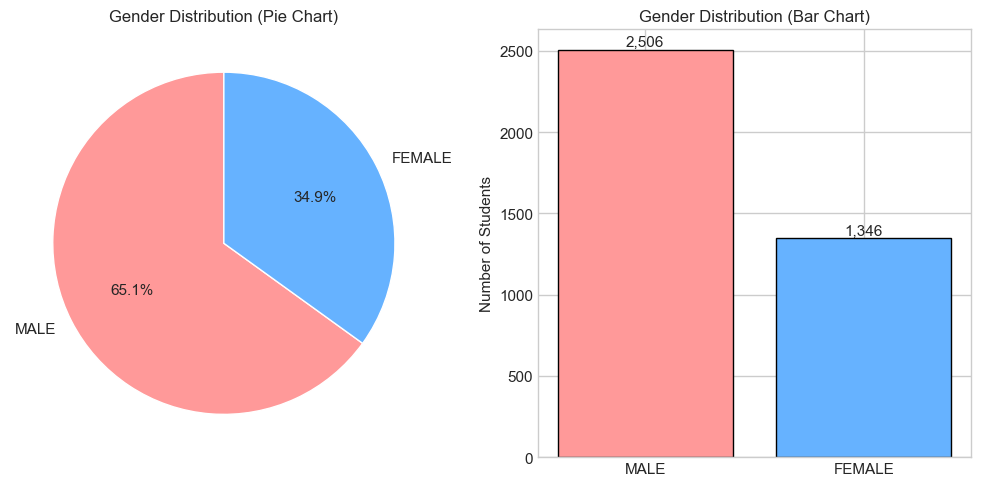


🌍 Country of Citizenship (Top 10):
  • INDIA: 2,697 (70.0%)
  • GHANA: 301 (7.8%)
  • NIGERIA: 277 (7.2%)
  • NEPAL: 101 (2.6%)
  • PAKISTAN: 76 (2.0%)
  • KENYA: 46 (1.2%)
  • GAMBIA, THE: 39 (1.0%)
  • BANGLADESH: 35 (0.9%)
  • CHINA: 35 (0.9%)
  • IRAN: 27 (0.7%)


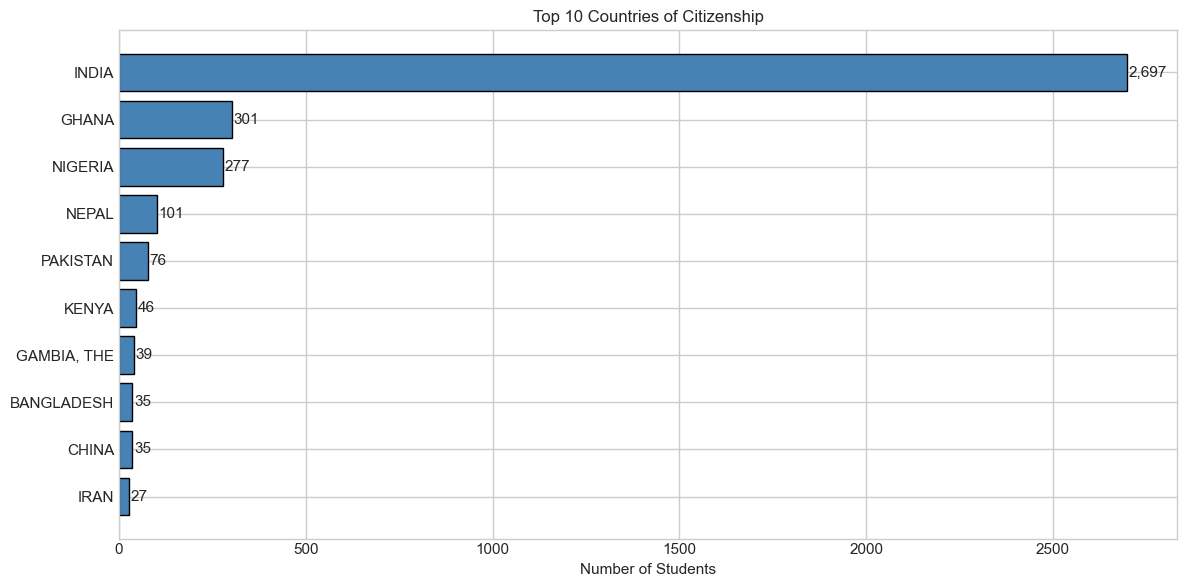


3. FINANCIAL ANALYSIS
----------------------------------------

💰 Financial Summary Statistics:
------------------------------
                        Metric  Count    Mean  Median     Std    Min      Max
                  Tuition Fees   3852 $25,514 $21,000 $11,405 $7,055  $65,000
               Living Expenses   3852 $18,231 $18,150  $1,546     $0  $22,100
            Dependent Expenses   3840    $110      $0  $1,087     $0  $24,000
      Student's Personal Funds   3852  $6,970      $0 $15,365     $0  $95,000
        Funds From This School   3849  $5,718  $1,000 $11,117     $0  $76,964
      Funds From Other Sources   3846 $34,115 $38,150 $18,626     $0 $250,000
Number of Months (for funding)   3852     9.0     9.0     0.6    4.0     12.0

📈 Financial Distributions:


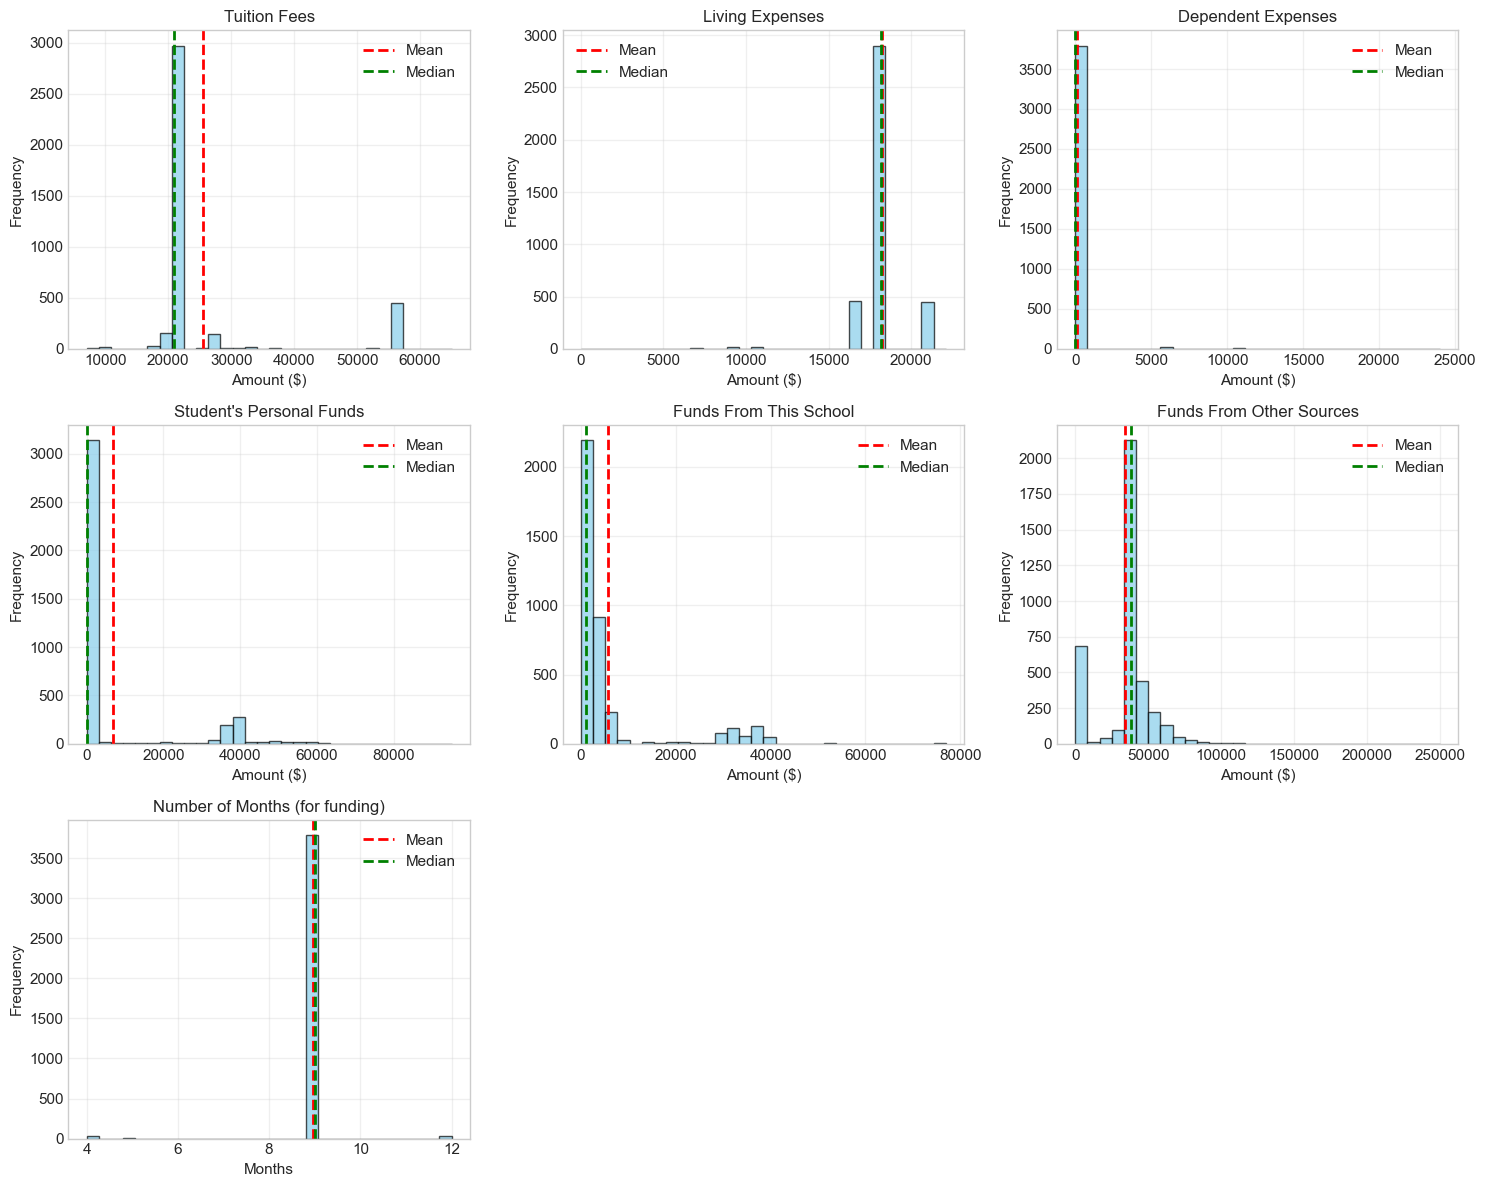


📦 Outlier Detection (Boxplots):


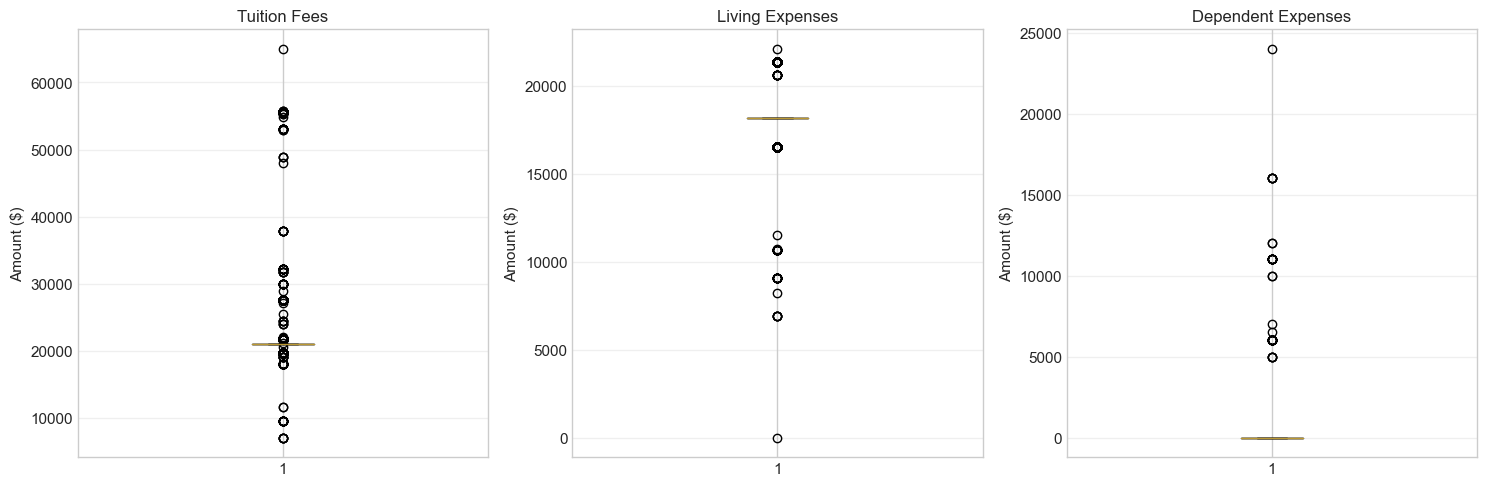


🔗 Correlation Analysis:


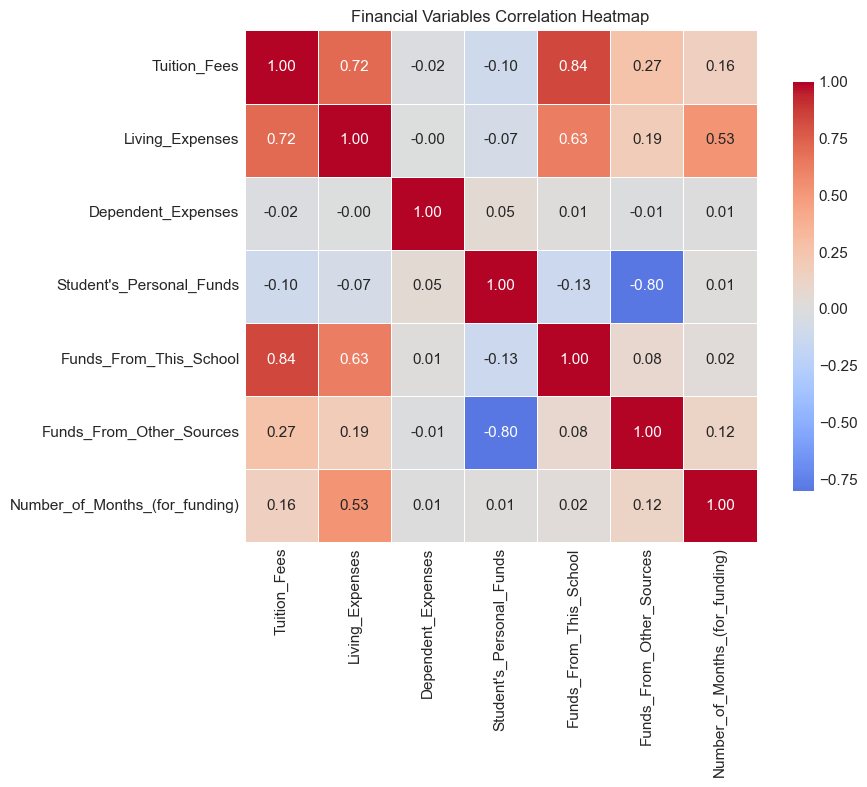

Strong Correlations (> 0.5):
  • Tuition_Fees ↔ Living_Expenses: 0.718
  • Tuition_Fees ↔ Funds_From_This_School: 0.838
  • Living_Expenses ↔ Funds_From_This_School: 0.631
  • Living_Expenses ↔ Number_of_Months_(for_funding): 0.527
  • Student's_Personal_Funds ↔ Funds_From_Other_Sources: -0.801

4. ACADEMIC ANALYSIS
----------------------------------------

🎓 Education Level Distribution:
  • MASTER'S: 3,308 (85.9%)
  • BACHELOR'S: 443 (11.5%)
  • DOCTORATE: 44 (1.1%)
  • OTHER: 36 (0.9%)
  • LANGUAGE TRAINING: 21 (0.5%)


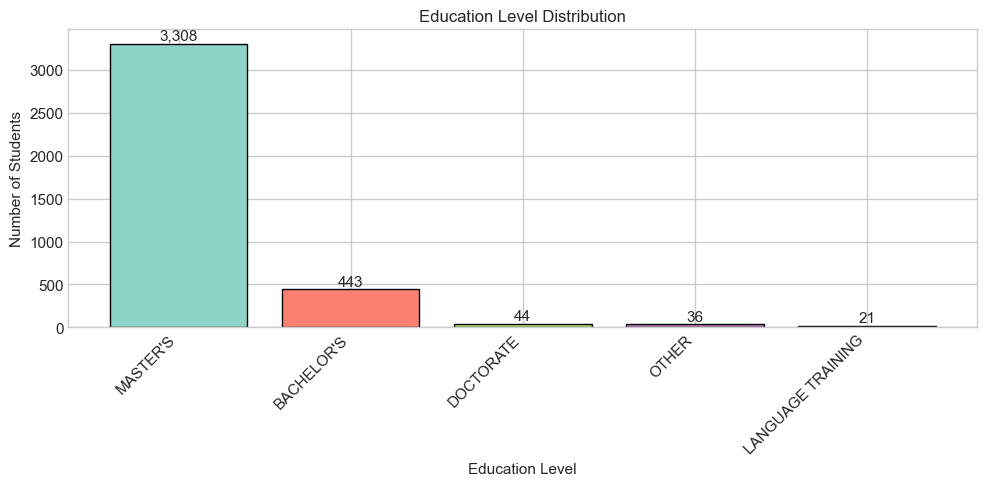


📚 Top 10 Majors:
  • Computer and Information Sciences, General: 939 (24.4%)
  • Computer Science: 637 (16.5%)
  • Informatics: 381 (9.9%)
  • Medical Informatics: 353 (9.2%)
  • Cyber/Electronic Operations and Warfare: 180 (4.7%)
  • Engineering, General: 161 (4.2%)
  • Management Science: 159 (4.1%)
  • Business Administration and Management, General: 94 (2.4%)
  • Epidemiology: 87 (2.3%)
  • Artificial Intelligence: 87 (2.3%)


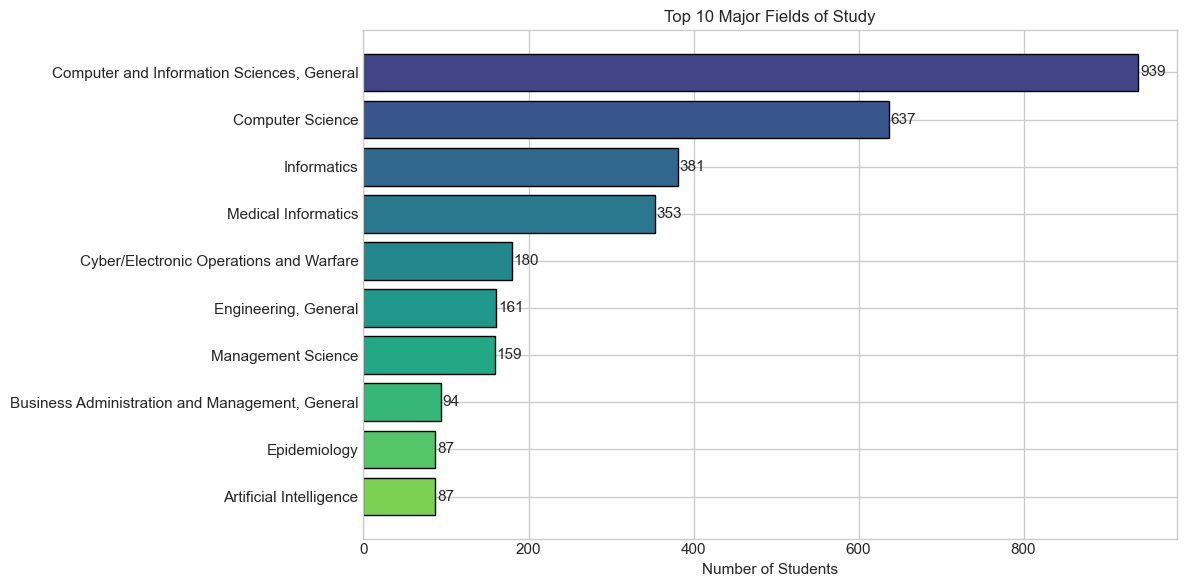


5. MISSING VALUE ANALYSIS
----------------------------------------
Total missing values: 11,591
Columns with missing values: 20/49

📊 Top 10 Columns with Missing Values:
                           Missing_Count  Missing_Percentage
Foreign_Address_2                   2082               54.05
I-901_Fee_Payment_Receipt           1744               45.28
I-901_Transaction_Amount            1744               45.28
I-901_Transaction_Date              1744               45.28
I-901_Transaction_Type              1744               45.28
Foreign_Postal_Code                  704               18.28
Other_Source_Type                    685               17.78
School_Fund_Type                     528               13.71
Overall_Remarks                      402               10.44
Given_Name                           150                3.89

6. KEY INSIGHTS & INTERPRETATIONS
----------------------------------------

🔍 MAJOR FINDINGS:

1. DEMOGRAPHIC PATTERNS:
   • Gender distribution shows MALE s

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("="*70)
print("EXPLORATORY DATA ANALYSIS (EDA) REPORT")
print("="*70)

# ============================================
# 1. DATASET OVERVIEW
# ============================================

print("\n1. DATASET OVERVIEW")
print("-"*40)

total_students = len(df_clean)
print(f"• Total Records: {total_students:,} students")
print(f"• Features: {df_clean.shape[1]} columns")
print(f"• Data Types:")
for dtype, count in df_clean.dtypes.value_counts().items():
    print(f"  - {dtype}: {count} columns")

# ============================================
# 2. DEMOGRAPHIC ANALYSIS
# ============================================

print("\n2. DEMOGRAPHIC ANALYSIS")
print("-"*40)

# Gender Distribution
if 'Gender' in df_clean.columns:
    gender_counts = df_clean['Gender'].value_counts()
    print(f"\n📊 Gender Distribution:")
    for gender, count in gender_counts.items():
        pct = count/total_students*100
        print(f"  • {gender}: {count:,} ({pct:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    colors = ['#FF9999', '#66B2FF'][:len(gender_counts)]
    plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
    plt.title('Gender Distribution (Pie Chart)')
    
    plt.subplot(1, 2, 2)
    bars = plt.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black')
    plt.title('Gender Distribution (Bar Chart)')
    plt.ylabel('Number of Students')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5, 
                f'{int(height):,}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Country Analysis
if 'Country_of_Citizenship' in df_clean.columns:
    country_counts = df_clean['Country_of_Citizenship'].value_counts()
    top_10 = country_counts.head(10)
    
    print(f"\n🌍 Country of Citizenship (Top 10):")
    for country, count in top_10.items():
        pct = count/total_students*100
        print(f"  • {country}: {count:,} ({pct:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(12, 6))
    bars = plt.barh(range(len(top_10)), top_10.values, color='steelblue', edgecolor='black')
    plt.title('Top 10 Countries of Citizenship')
    plt.xlabel('Number of Students')
    plt.yticks(range(len(top_10)), top_10.index)
    plt.gca().invert_yaxis()
    
    for i, (country, count) in enumerate(top_10.items()):
        plt.text(count + 5, i, f'{count:,}', va='center')
    
    plt.tight_layout()
    plt.show()

# ============================================
# 3. FINANCIAL ANALYSIS
# ============================================

print("\n3. FINANCIAL ANALYSIS")
print("-"*40)

financial_cols = ['Tuition_Fees', 'Living_Expenses', 'Dependent_Expenses', 
                  "Student's_Personal_Funds", 'Funds_From_This_School', 
                  'Funds_From_Other_Sources', 'Number_of_Months_(for_funding)']

available_financial = [col for col in financial_cols if col in df_clean.columns]

if available_financial:
    print(f"\n💰 Financial Summary Statistics:")
    print("-"*30)
    
    summary_data = []
    for col in available_financial:
        data = df_clean[col].dropna()
        if len(data) > 0:
            is_money = 'Months' not in col
            prefix = '$' if is_money else ''
            
            summary_data.append({
                'Metric': col.replace('_', ' '),
                'Count': len(data),
                'Mean': f"{prefix}{data.mean():,.0f}" if is_money else f"{data.mean():.1f}",
                'Median': f"{prefix}{data.median():,.0f}" if is_money else f"{data.median():.1f}",
                'Std': f"{prefix}{data.std():,.0f}" if is_money else f"{data.std():.1f}",
                'Min': f"{prefix}{data.min():,.0f}" if is_money else f"{data.min():.1f}",
                'Max': f"{prefix}{data.max():,.0f}" if is_money else f"{data.max():.1f}"
            })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Histograms for financial data
    print(f"\n📈 Financial Distributions:")
    
    n_cols = min(len(available_financial), 3)
    n_rows = (len(available_financial) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, col in enumerate(available_financial):
        if idx < len(axes):
            ax = axes[idx]
            data = df_clean[col].dropna()
            
            if len(data) > 0:
                ax.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
                ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean')
                ax.axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median')
                
                ax.set_title(col.replace('_', ' '))
                ax.set_xlabel('Amount ($)' if 'Months' not in col else 'Months')
                ax.set_ylabel('Frequency')
                ax.legend()
                ax.grid(alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(available_financial), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Boxplots for outlier detection
    print(f"\n📦 Outlier Detection (Boxplots):")
    
    fig, axes = plt.subplots(1, min(len(available_financial), 3), figsize=(15, 5))
    axes = axes.flatten() if hasattr(axes, '__len__') else [axes]
    
    for idx, col in enumerate(available_financial[:3]):  # Show first 3
        if idx < len(axes):
            ax = axes[idx]
            data = df_clean[col].dropna()
            
            if len(data) > 0:
                ax.boxplot(data, vert=True)
                ax.set_title(col.replace('_', ' '))
                ax.set_ylabel('Amount ($)' if 'Months' not in col else 'Months')
                ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation Analysis
    print(f"\n🔗 Correlation Analysis:")
    
    numeric_for_corr = [col for col in available_financial if df_clean[col].notna().sum() > 100]
    
    if len(numeric_for_corr) >= 3:
        corr_matrix = df_clean[numeric_for_corr].corr()
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title('Financial Variables Correlation Heatmap')
        plt.tight_layout()
        plt.show()
        
        # Find strong correlations
        strong_corrs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.5:
                    strong_corrs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
        
        if strong_corrs:
            print("Strong Correlations (> 0.5):")
            for col1, col2, corr in strong_corrs:
                print(f"  • {col1} ↔ {col2}: {corr:.3f}")
        else:
            print("  No strong correlations (> 0.5) found")
    
else:
    print("  No financial columns available")

# ============================================
# 4. ACADEMIC ANALYSIS
# ============================================

print("\n4. ACADEMIC ANALYSIS")
print("-"*40)

# Education Level
if 'Education_Level' in df_clean.columns:
    edu_counts = df_clean['Education_Level'].value_counts()
    
    print(f"\n🎓 Education Level Distribution:")
    for level, count in edu_counts.items():
        pct = count/total_students*100
        print(f"  • {level}: {count:,} ({pct:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(10, 5))
    colors = plt.cm.Set3(np.linspace(0, 1, len(edu_counts)))
    bars = plt.bar(edu_counts.index, edu_counts.values, color=colors, edgecolor='black')
    plt.title('Education Level Distribution')
    plt.xlabel('Education Level')
    plt.ylabel('Number of Students')
    plt.xticks(rotation=45, ha='right')
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5, 
                f'{int(height):,}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Major Analysis
if 'Major_1_Description' in df_clean.columns:
    major_counts = df_clean['Major_1_Description'].value_counts()
    top_majors = major_counts.head(10)
    
    print(f"\n📚 Top 10 Majors:")
    for major, count in top_majors.items():
        pct = count/total_students*100
        print(f"  • {major}: {count:,} ({pct:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(12, 6))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_majors)))
    plt.barh(range(len(top_majors)), top_majors.values, color=colors, edgecolor='black')
    plt.title('Top 10 Major Fields of Study')
    plt.xlabel('Number of Students')
    plt.yticks(range(len(top_majors)), top_majors.index)
    plt.gca().invert_yaxis()
    
    for i, (major, count) in enumerate(top_majors.items()):
        plt.text(count + 2, i, f'{count:,}', va='center')
    
    plt.tight_layout()
    plt.show()

# ============================================
# 5. MISSING VALUE ANALYSIS
# ============================================

print("\n5. MISSING VALUE ANALYSIS")
print("-"*40)

missing_counts = df_clean.isna().sum()
missing_pct = (missing_counts / total_students * 100).round(2)

missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Percentage', ascending=False)

print(f"Total missing values: {missing_counts.sum():,}")
print(f"Columns with missing values: {(missing_counts > 0).sum()}/{df_clean.shape[1]}")

# Show top 10 columns with missing values
print("\n📊 Top 10 Columns with Missing Values:")
print(missing_df.head(10).to_string())

# ============================================
# 6. KEY INSIGHTS & INTERPRETATIONS
# ============================================

print("\n6. KEY INSIGHTS & INTERPRETATIONS")
print("-"*40)

print("\n🔍 MAJOR FINDINGS:")

# Insight 1: Demographic Patterns
print("\n1. DEMOGRAPHIC PATTERNS:")
if 'Gender' in df_clean.columns:
    gender_counts = df_clean['Gender'].value_counts()
    if len(gender_counts) >= 2:
        print(f"   • Gender distribution shows {gender_counts.idxmax()} students are the majority")
        print(f"   • Ratio: {gender_counts['M']/gender_counts['F']:.1f}:1 (M:F)" if 'M' in gender_counts and 'F' in gender_counts else "")

if 'Country_of_Citizenship' in df_clean.columns:
    top_country = df_clean['Country_of_Citizenship'].mode().iloc[0]
    top_count = df_clean['Country_of_Citizenship'].value_counts().iloc[0]
    print(f"   • {top_country} is the most represented country ({top_count:,} students)")
    print(f"   • Top country represents {top_count/total_students*100:.1f}% of all students")

# Insight 2: Financial Patterns
print("\n2. FINANCIAL PATTERNS:")
if 'Tuition_Fees' in df_clean.columns:
    tuition_std = df_clean['Tuition_Fees'].std()
    tuition_mean = df_clean['Tuition_Fees'].mean()
    print(f"   • Tuition fees show ${tuition_std:,.0f} standard deviation")
    print(f"   • Average tuition: ${tuition_mean:,.0f}")

if "Student's_Personal_Funds" in df_clean.columns:
    zero_funds = (df_clean["Student's_Personal_Funds"] == 0).sum()
    print(f"   • {zero_funds/total_students*100:.1f}% of students report $0 personal funds")

# Insight 3: Academic Patterns
print("\n3. ACADEMIC PATTERNS:")
if 'Education_Level' in df_clean.columns:
    top_edu = df_clean['Education_Level'].mode().iloc[0]
    print(f"   • {top_edu} is the most common education level")

if 'Major_1_Description' in df_clean.columns:
    unique_majors = df_clean['Major_1_Description'].nunique()
    print(f"   • Students are distributed across {unique_majors} different majors")

# Insight 4: Data Quality
print("\n4. DATA QUALITY:")
missing_cols = (missing_counts > 0).sum()
print(f"   • {missing_cols} columns contain missing values")
print(f"   • {(df_clean.shape[1] - missing_cols)} columns are complete")
print(f"   • Overall data completeness: {(1 - missing_counts.sum()/(total_students*df_clean.shape[1]))*100:.1f}%")

# ============================================
# 7. SUMMARY & RECOMMENDATIONS
# ============================================

print("\n7. SUMMARY & RECOMMENDATIONS")
print("-"*40)

print("\n📋 QUICK STATISTICS:")
print(f"• Total students analyzed: {total_students:,}")
print(f"• Features analyzed: {df_clean.shape[1]}")
print(f"• Financial variables: {len(available_financial) if 'available_financial' in locals() else 0}")

print("\n🎯 RECOMMENDATIONS:")
print("1. Consider imputing missing values in key columns")
print("2. Standardize categorical values (countries, majors)")
print("3. Investigate outliers in financial variables")
print("4. Explore correlations for predictive modeling")

print("\n" + "="*70)
print("✅ EDA REPORT COMPLETE")
print("="*70)
print(f"\nReport generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Visualizations created: Bar charts, histograms, boxplots, heatmap")
print(f"Analysis completed: Demographics, Finances, Academics, Data Quality")

In [6]:
# Save your cleaned dataframe
df_clean.to_csv('cleaned_outreach_data.csv', index=False)
print("File saved: cleaned_outreach_data.csv")

File saved: cleaned_outreach_data.csv


In [25]:
import pandas as pd
import numpy as np
from datetime import datetime

print("="*70)
print("DATA DICTIONARY GENERATOR")
print("="*70)

# Create data dictionary
data_dict = []

for col in df_clean.columns:
    col_data = df_clean[col]
    
    # Basic info
    variable_name = col
    data_type = str(col_data.dtype)
    
    # Get example values
    non_null = col_data.dropna()
    if len(non_null) > 0:
        example_values = non_null.head(3).tolist()
        # Clean up example values for display
        example_str = ", ".join([str(x) for x in example_values[:3]])
        if len(example_str) > 50:
            example_str = example_str[:47] + "..."
    else:
        example_str = "No data"
    
    # Get unique categories for categorical data
    if col_data.dtype == 'object' or col_data.dtype.name == 'category':
        unique_categories = col_data.dropna().unique()
        num_unique = len(unique_categories)
        if num_unique <= 10:
            categories_str = ", ".join([str(x) for x in unique_categories[:10]])
        else:
            categories_str = f"{num_unique} unique values"
            top_categories = col_data.value_counts().head(5).index.tolist()
            categories_str += f" (Top 5: {', '.join([str(x) for x in top_categories])})"
    else:
        categories_str = "N/A (Numeric)"
    
    # Generate description based on column name
    description = ""
    col_lower = col.lower()
    
    # Pattern matching for descriptions
    if 'id' in col_lower or 'sevis' in col_lower:
        description = "Unique identifier"
    elif 'name' in col_lower:
        if 'given' in col_lower or 'first' in col_lower:
            description = "Student's first/given name"
        elif 'surname' in col_lower or 'last' in col_lower:
            description = "Student's surname/family name"
        elif 'preferred' in col_lower:
            description = "Student's preferred name"
        elif 'school' in col_lower:
            description = "School/institution name"
        elif 'campus' in col_lower:
            description = "Campus name"
        elif 'major' in col_lower:
            description = "Major/field of study"
        else:
            description = "Name field"
    elif 'date' in col_lower:
        if 'birth' in col_lower:
            description = "Date of birth"
        elif 'start' in col_lower:
            description = "Program/session start date"
        elif 'end' in col_lower:
            description = "Program/session end date"
        elif 'change' in col_lower:
            description = "Status change date"
        elif 'entry' in col_lower:
            description = "Date of entry to country"
        elif 'departure' in col_lower:
            description = "Date of departure"
        else:
            description = "Date field"
    elif 'gender' in col_lower:
        description = "Gender identity"
    elif 'country' in col_lower:
        if 'citizen' in col_lower:
            description = "Country of citizenship"
        elif 'birth' in col_lower:
            description = "Country of birth"
        else:
            description = "Country information"
    elif 'tuition' in col_lower or 'fee' in col_lower:
        description = "Tuition and fees amount (USD)"
    elif 'expense' in col_lower:
        description = "Living/dependent expenses (USD)"
    elif 'fund' in col_lower:
        description = "Funding source amount (USD)"
    elif 'month' in col_lower:
        description = "Number of months for funding"
    elif 'email' in col_lower:
        description = "Email address"
    elif 'phone' in col_lower or 'telephone' in col_lower:
        description = "Contact phone number"
    elif 'address' in col_lower:
        description = "Physical/mailing address"
    elif 'city' in col_lower:
        description = "City name"
    elif 'state' in col_lower:
        description = "State/Province"
    elif 'postal' in col_lower or 'zip' in col_lower:
        description = "Postal/ZIP code"
    elif 'education' in col_lower or 'level' in col_lower:
        description = "Education level/degree"
    elif 'major' in col_lower:
        description = "Major field of study"
    elif 'program' in col_lower:
        description = "Academic program information"
    elif 'visa' in col_lower:
        description = "Visa information"
    elif 'passport' in col_lower:
        description = "Passport information"
    elif 'opt' in col_lower or 'cpt' in col_lower:
        description = "Optional Practical Training information"
    elif 'status' in col_lower:
        description = "Current SEVIS status"
    elif 'transaction' in col_lower:
        description = "Financial transaction details"
    elif 'remarks' in col_lower or 'comment' in col_lower:
        description = "Additional comments/remarks"
    else:
        description = "Data field"
    
    # Generate notes/warnings about irregularities
    notes = []
    
    # Missing values check
    missing_count = col_data.isna().sum()
    missing_pct = (missing_count / len(df_clean)) * 100
    if missing_pct > 0:
        notes.append(f"Missing: {missing_count} values ({missing_pct:.1f}%)")
    
    # Data type specific checks
    if col_data.dtype == 'object':
        # Check for inconsistent formatting
        if col_data.dropna().apply(lambda x: isinstance(x, str)).all():
            lengths = col_data.dropna().str.len()
            if lengths.nunique() > 1:
                avg_len = lengths.mean()
                notes.append(f"Variable text length (avg: {avg_len:.0f} chars)")
    
    elif np.issubdtype(col_data.dtype, np.number):
        # Numeric checks
        if col_data.dropna().min() < 0:
            notes.append("Contains negative values")
        if (col_data == 0).sum() > len(df_clean) * 0.5:  # More than 50% zeros
            notes.append("High proportion of zero values")
        
        # Check for outliers (simplified)
        if len(col_data.dropna()) > 10:
            q1 = col_data.quantile(0.25)
            q3 = col_data.quantile(0.75)
            iqr = q3 - q1
            if iqr > 0:
                outliers = ((col_data < (q1 - 1.5*iqr)) | (col_data > (q3 + 1.5*iqr))).sum()
                if outliers > 0:
                    notes.append(f"Potential outliers: {outliers}")
    
    # Join notes
    notes_str = "; ".join(notes) if notes else "No issues detected"
    
    # Add to dictionary
    data_dict.append({
        'Variable Name': variable_name,
        'Description': description,
        'Data Type': data_type,
        'Example Values': example_str,
        'Unique Categories': categories_str,
        'Notes/Warnings': notes_str,
        'Missing Values': f"{missing_count} ({missing_pct:.1f}%)",
        'Total Records': len(df_clean)
    })

# Create DataFrame
data_dict_df = pd.DataFrame(data_dict)

# Save to Excel with formatting
output_file = "SEVIS_Data_Dictionary.xlsx"

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Write main data dictionary
    data_dict_df.to_excel(writer, sheet_name='Data Dictionary', index=False)
    
    # Get the workbook and worksheet
    workbook = writer.book
    worksheet = writer.sheets['Data Dictionary']
    
    # Auto-adjust column widths
    for column in worksheet.columns:
        max_length = 0
        column_letter = column[0].column_letter
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = min(max_length + 2, 50)  # Cap at 50
        worksheet.column_dimensions[column_letter].width = adjusted_width

# Also create a CSV version for easy viewing
data_dict_df.to_csv("SEVIS_Data_Dictionary.csv", index=False)

print(f"\n✅ Data Dictionary created successfully!")
print(f"   • Excel file: {output_file}")
print(f"   • CSV file: SEVIS_Data_Dictionary.csv")
print(f"   • Total variables documented: {len(data_dict_df)}")

# Display summary
print("\n" + "="*70)
print("DATA DICTIONARY SUMMARY")
print("="*70)

# Count by data type
print(f"\n📊 Data Types Summary:")
type_counts = data_dict_df['Data Type'].value_counts()
for dtype, count in type_counts.items():
    print(f"   • {dtype}: {count} variables")

# Variables with warnings
warn_vars = data_dict_df[data_dict_df['Notes/Warnings'] != 'No issues detected']
print(f"\n⚠️  Variables with Warnings: {len(warn_vars)}")
if len(warn_vars) > 0:
    for _, row in warn_vars.head(5).iterrows():
        print(f"   • {row['Variable Name']}: {row['Notes/Warnings']}")
    if len(warn_vars) > 5:
        print(f"   ... and {len(warn_vars) - 5} more")

# Variables with high missing values
high_missing = data_dict_df[data_dict_df['Missing Values'].str.contains(r'\(\d{2,}\.\d%\)')]
print(f"\n🔍 Variables with >10% missing values: {len(high_missing)}")

# Display sample of data dictionary
print(f"\n👀 SAMPLE OF DATA DICTIONARY (first 10 variables):")
print("-"*80)
sample_df = data_dict_df.head(10)[['Variable Name', 'Description', 'Data Type', 'Missing Values']]
print(sample_df.to_string(index=False))

# Generate markdown version for documentation
print(f"\n📄 Markdown version available:")
print("-"*40)
print("```markdown")
print("# SEVIS Dataset Data Dictionary")
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total Variables: {len(data_dict_df)}")
print(f"Total Records: {len(df_clean)}")
print("\n## Quick Statistics")
print(f"- Object/String columns: {len(data_dict_df[data_dict_df['Data Type'] == 'object'])}")
print(f"- Numeric columns: {len(data_dict_df[data_dict_df['Data Type'].str.contains('int|float')])}")
print(f"- Columns with warnings: {len(warn_vars)}")
print(f"- Columns with >10% missing: {len(high_missing)}")
print("\n## Key Variables")
key_vars = ['SEVIS_ID', 'Gender', 'Country_of_Citizenship', 'Tuition_Fees', 
            'Education_Level', 'Major_1_Description']
for var in key_vars:
    if var in df_clean.columns:
        info = data_dict_df[data_dict_df['Variable Name'] == var].iloc[0]
        print(f"\n### {var}")
        print(f"- **Description**: {info['Description']}")
        print(f"- **Type**: {info['Data Type']}")
        print(f"- **Missing**: {info['Missing Values']}")
        print(f"- **Notes**: {info['Notes/Warnings']}")
print("```")

print("\n" + "="*70)
print("📋 DATA DICTIONARY CONTENTS")
print("="*70)
print("""
The generated data dictionary includes:

1. VARIABLE NAME: Column name from dataset
2. DESCRIPTION: Human-readable description based on column name patterns
3. DATA TYPE: Pandas data type (object, int64, float64, datetime64)
4. EXAMPLE VALUES: Sample actual values from the dataset
5. UNIQUE CATEGORIES: For categorical variables, lists unique values
6. NOTES/WARNINGS: Data quality issues, missing values, outliers
7. MISSING VALUES: Count and percentage of missing data
8. TOTAL RECORDS: Number of rows in dataset

Files created:
• SEVIS_Data_Dictionary.xlsx - Excel spreadsheet with formatting
• SEVIS_Data_Dictionary.csv - CSV version for easy viewing
""")

DATA DICTIONARY GENERATOR

✅ Data Dictionary created successfully!
   • Excel file: SEVIS_Data_Dictionary.xlsx
   • CSV file: SEVIS_Data_Dictionary.csv
   • Total variables documented: 49

DATA DICTIONARY SUMMARY

📊 Data Types Summary:
   • object: 35 variables
   • float64: 8 variables
   • int64: 6 variables

⚠️  Variables with Warnings: 40
   • NonImmigrant_ID: Potential outliers: 88
   • Status_Change_Date: Variable text length (avg: 9 chars)
   • Surname_Or_Primary_Name: Variable text length (avg: 7 chars)
   • Given_Name: Missing: 150 values (3.9%); Variable text length (avg: 11 chars)
   • Preferred_Name: Variable text length (avg: 13 chars)
   ... and 35 more

🔍 Variables with >10% missing values: 9

👀 SAMPLE OF DATA DICTIONARY (first 10 variables):
--------------------------------------------------------------------------------
          Variable Name                   Description Data Type Missing Values
               SEVIS_ID             Unique identifier    object       0 